In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\orders.csv")

prior = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__prior.csv")

train = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__train.csv")

products = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\products.csv")

aisles = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\aisles.csv")

departments = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\departments.csv")

# Results and Comparison of Customer Segmentation Approaches

## Data Preparation

This notebook combines the previously generated outputs from the cohort analysis and the three customer segmentation approaches: RFM-based K-Means clustering, Louvain community detection, and autoencoder-based K-Means clustering.

The integrated analytical dataset (`preprocessed_df`) from `01_data_understanding_preprocessing_cohort_analysis.ipynb` is recreated for transaction-level segment analysis.

The customer-level outputs generated in the previous notebooks are then loaded and merged into a single comparison dataset (`comparison_df`). This dataset contains each customer’s cohort assignment, RFM-based segment, Louvain segment, and autoencoder-based segment, and serves as the basis for the comparative analysis.

In [2]:
# Load generated segmentation and cohort outputs
cohorts = pd.read_csv(r"C:\Users\matth\Downloads\Networkbased customer segmentation seminar\customer_cohorts.csv")

rfm_segments = pd.read_csv(r"C:\Users\matth\Downloads\Networkbased customer segmentation seminar\rfm_kmeans_customer_segments.csv")

louvain_segments = pd.read_csv(r"C:\Users\matth\Downloads\Networkbased customer segmentation seminar\louvain_customer_segments.csv")

ae_segments = pd.read_csv(r"C:\Users\matth\Downloads\Networkbased customer segmentation seminar\autoencoder_kmeans_customer_segments.csv")

In [3]:
# Combine prior and train order-product datasets
order_products = pd.concat([prior, train],axis=0,ignore_index=True)

# Merge with orders table
preprocessed_df = order_products.merge(orders,on="order_id",how="left")

# Merge with products table
preprocessed_df = preprocessed_df.merge(products,on="product_id",how="left")

# Merge with aisles table
preprocessed_df = preprocessed_df.merge(aisles,on="aisle_id",how="left")

# Merge with departments table
preprocessed_df = preprocessed_df.merge(departments,on="department_id",how="left")

print("Final preprocessed dataset:")
print(preprocessed_df.isnull().sum())
print("Duplicates:", preprocessed_df.duplicated().sum())
print(preprocessed_df.shape)
preprocessed_df.head()

Final preprocessed dataset:
order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64
Duplicates: 0
(33819106, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [4]:
# Combine all customer-level outputs
comparison_df = (cohorts
                .merge(rfm_segments, on="user_id", how="left")
                .merge(louvain_segments, on="user_id", how="left")
                .merge(ae_segments, on="user_id", how="left"))

print(comparison_df.shape)
print(comparison_df.isnull().sum())
comparison_df.head()

(206209, 10)
user_id                       0
orders_first_14_days          0
cohort                        0
total_orders                  0
F_total_orders                0
R_avg_days_between_orders     0
M_avg_products_per_order      0
rfm_kmeans_segment            0
louvain_segment               0
autoencoder_kmeans_segment    0
dtype: int64


,user_id,orders_first_14_days,cohort,total_orders,F_total_orders,R_avg_days_between_orders,M_avg_products_per_order,rfm_kmeans_segment,louvain_segment,autoencoder_kmeans_segment
0,1,1,Low Activity,11,11,19.000000,6.363636,1,1,1
1,2,3,Medium Activity,15,15,16.285714,15.066667,0,0,0
2,3,2,Medium Activity,13,13,12.000000,7.333333,3,2,1
3,4,1,Low Activity,6,6,17.000000,3.600000,1,1,0
4,5,2,Medium Activity,5,5,11.500000,9.200000,3,3,1


## Segment Size Comparison
This section compares the number and relative share of customers assigned to each segment across the three segmentation approaches. The purpose is to assess whether the methods produce balanced or highly uneven segment structures.

In [5]:
# RFM segment sizes
rfm_segment_sizes = comparison_df["rfm_kmeans_segment"].value_counts().sort_index().reset_index()
rfm_segment_sizes["percentage"] = (rfm_segment_sizes["count"] / rfm_segment_sizes["count"].sum() * 100).round(2)
rfm_segment_sizes

,rfm_kmeans_segment,count,percentage
0,0,38120,18.49
1,1,67425,32.70
2,2,21924,10.63
3,3,78740,38.18


In [6]:
# Louvain segment sizes
louvain_segment_sizes = comparison_df["louvain_segment"].value_counts().sort_index().reset_index()
louvain_segment_sizes["percentage"] = (louvain_segment_sizes["count"] / louvain_segment_sizes["count"].sum() * 100).round(2)

louvain_segment_sizes

,louvain_segment,count,percentage
0,0,27465,13.32
1,1,59523,28.87
2,2,30950,15.01
3,3,35699,17.31
4,4,52572,25.49


In [7]:
# Autoencoder segment sizes
ae_segment_sizes = comparison_df["autoencoder_kmeans_segment"].value_counts().sort_index().reset_index()
ae_segment_sizes["percentage"] = (ae_segment_sizes["count"] / ae_segment_sizes["count"].sum() * 100).round(2)
ae_segment_sizes

,autoencoder_kmeans_segment,count,percentage
0,0,57631,27.95
1,1,123348,59.82
2,2,20843,10.11
3,3,4387,2.13


## Overall Aisle Purchase Distribution

Before comparing aisle preferences across segments, the overall aisle purchase distribution is examined to identify generally dominant aisles in the dataset. 

In [8]:
# Calculate overall purchase counts and shares by aisle
overall_top_aisles = preprocessed_df.groupby("aisle")["product_id"].count().reset_index(name="purchase_count")

overall_top_aisles["overall_purchase_share"] = (overall_top_aisles["purchase_count"]/ overall_top_aisles["purchase_count"].sum()* 100).round(2)

overall_top_aisles = overall_top_aisles.sort_values("purchase_count", ascending=False)
overall_top_aisles.head(20)

,aisle,purchase_count,overall_purchase_share
50,fresh fruits,3792661,11.21
53,fresh vegetables,3568630,10.55
98,packaged vegetables fruits,1843806,5.45
133,yogurt,1507583,4.46
93,packaged cheese,1021462,3.02
83,milk,923659,2.73
131,water seltzer sparkling water,878150,2.60
25,chips pretzels,753739,2.23
119,soy lactosefree,664493,1.96
11,bread,608469,1.80


## RFM Segment Profiling

The RFM-based segments are profiled using the three behavioral variables that were also used for clustering: average days between orders, total number of orders, and average number of products per order. In addition, aisle-level representation ratios are calculated to examine whether the RFM segments also differ in terms of product-category preferences.


In [9]:
# Calculate average RFM values per segment
rfm_profile = comparison_df.groupby("rfm_kmeans_segment")[["R_avg_days_between_orders", "F_total_orders", "M_avg_products_per_order"]].mean().round(2)

# Add segment size and percentage share
rfm_profile["customer_count"] = comparison_df["rfm_kmeans_segment"].value_counts().sort_index()
rfm_profile["percentage"] = (rfm_profile["customer_count"] / rfm_profile["customer_count"].sum() * 100).round(2)

rfm_profile

,R_avg_days_between_orders,F_total_orders,M_avg_products_per_order,customer_count,percentage
rfm_kmeans_segment,,,,,
0,16.29,12.39,18.96,38120,18.49
1,22.68,7.39,7.45,67425,32.70
2,6.43,55.98,10.09,21924,10.63
3,11.36,15.54,7.78,78740,38.18


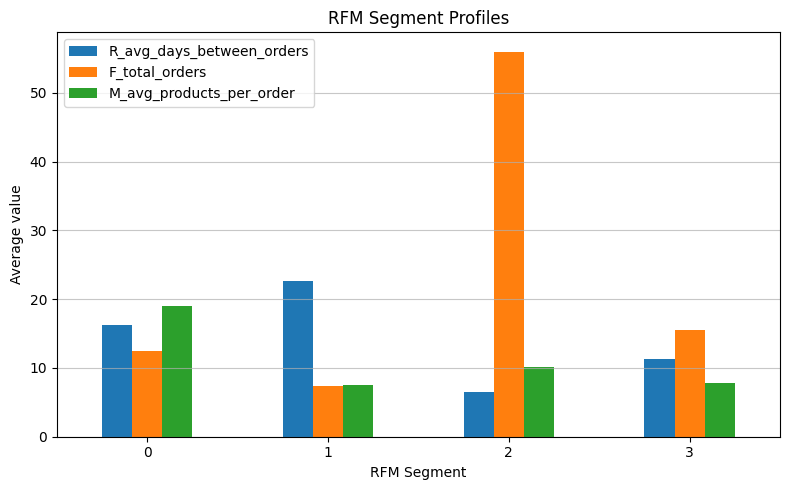

In [10]:
rfm_profile[["R_avg_days_between_orders", "F_total_orders", "M_avg_products_per_order"]].plot(kind="bar", figsize=(8,5))
plt.xlabel("RFM Segment")
plt.ylabel("Average value")
plt.title("RFM Segment Profiles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis="y", alpha=0.7)
plt.savefig("rfm_segment_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

### Aisle-Level Preferences by RFM Segment
This section examines whether the RFM segments also show differences in aisle-level purchase preferences.

In [11]:
# Add RFM-based K-Means segment labels to the preprocessed Instacart dataset
customer_transactions_rfm = preprocessed_df.merge(rfm_segments[["user_id", "rfm_kmeans_segment"]],on="user_id",how="left")

print(customer_transactions_rfm.shape)
print(customer_transactions_rfm["rfm_kmeans_segment"].isnull().sum())
customer_transactions_rfm.head()

(33819106, 16)
0


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,rfm_kmeans_segment
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs,1
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce,1
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry,1
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry,1
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry,1


In [12]:
# Count product purchases for each aisle within each RFM segment
rfm_aisle_profile = customer_transactions_rfm.groupby(["rfm_kmeans_segment", "aisle"])["product_id"].count().reset_index(name="segment_aisle_purchase_count")

# Total product purchases within each RFM segment
rfm_segment_totals = rfm_aisle_profile.groupby("rfm_kmeans_segment")["segment_aisle_purchase_count"].sum().reset_index(name="segment_total_purchase_count")

# Add total segment purchases to aisle profile
rfm_aisle_profile = rfm_aisle_profile.merge(rfm_segment_totals,on="rfm_kmeans_segment",how="left")

# Share of each aisle within its RFM segment
rfm_aisle_profile["segment_aisle_purchase_share"] = (rfm_aisle_profile["segment_aisle_purchase_count"]/ rfm_aisle_profile["segment_total_purchase_count"]* 100).round(2)

rfm_aisle_profile

,rfm_kmeans_segment,aisle,segment_aisle_purchase_count,segment_total_purchase_count,segment_aisle_purchase_share
0,0,air fresheners candles,5075,8793063,0.06
1,0,asian foods,47349,8793063,0.54
2,0,baby accessories,1980,8793063,0.02
3,0,baby bath body care,2386,8793063,0.03
4,0,baby food formula,128828,8793063,1.47
...,...,...,...,...,...
531,3,trash bags liners,10186,9392130,0.11
532,3,vitamins supplements,14023,9392130,0.15
533,3,water seltzer sparkling water,279316,9392130,2.97
534,3,white wines,13446,9392130,0.14


In [13]:
# Overall product purchases for each aisle across all customers
overall_aisle_purchases = customer_transactions_rfm.groupby("aisle")["product_id"].count().reset_index(name="overall_aisle_purchase_count")

# Share of each aisle across all product purchases in the full dataset
overall_aisle_purchases["overall_aisle_purchase_share"] = (overall_aisle_purchases["overall_aisle_purchase_count"]/ overall_aisle_purchases["overall_aisle_purchase_count"].sum()* 100).round(2)

# Add overall aisle purchase share to the segment-aisle profile
rfm_aisle_profile = rfm_aisle_profile.merge(overall_aisle_purchases[["aisle", "overall_aisle_purchase_share"]],on="aisle",how="left")

# Calculate aisle representation ratio
# Values above 1 indicate that an aisle is overrepresented in the segment compared to the overall dataset
rfm_aisle_profile["aisle_representation_ratio"] = (rfm_aisle_profile["segment_aisle_purchase_share"]/ rfm_aisle_profile["overall_aisle_purchase_share"]).round(2)

rfm_aisle_profile

,rfm_kmeans_segment,aisle,segment_aisle_purchase_count,segment_total_purchase_count,segment_aisle_purchase_share,overall_aisle_purchase_share,aisle_representation_ratio
0,0,air fresheners candles,5075,8793063,0.06,0.06,1.00
1,0,asian foods,47349,8793063,0.54,0.51,1.06
2,0,baby accessories,1980,8793063,0.02,0.03,0.67
3,0,baby bath body care,2386,8793063,0.03,0.03,1.00
4,0,baby food formula,128828,8793063,1.47,1.17,1.26
...,...,...,...,...,...,...,...
531,3,trash bags liners,10186,9392130,0.11,0.10,1.10
532,3,vitamins supplements,14023,9392130,0.15,0.14,1.07
533,3,water seltzer sparkling water,279316,9392130,2.97,2.60,1.14
534,3,white wines,13446,9392130,0.14,0.09,1.56


In [14]:
# Keep only relevant and overrepresented aisles
rfm_aisle_profile_relevant = rfm_aisle_profile[(rfm_aisle_profile["segment_aisle_purchase_share"] >= 1.0)& (rfm_aisle_profile["aisle_representation_ratio"] > 1.0)].copy()

# Rank relevant aisles within each RFM segment
rfm_aisle_profile_relevant["rank_by_representation_ratio"] = rfm_aisle_profile_relevant.groupby("rfm_kmeans_segment")["aisle_representation_ratio"].rank(method="first", ascending=False)

# Select top 10 relevant overrepresented aisles per RFM segment
top_ratio_aisles_rfm = rfm_aisle_profile_relevant[rfm_aisle_profile_relevant["rank_by_representation_ratio"] <= 10].sort_values(["rfm_kmeans_segment", "rank_by_representation_ratio"]).reset_index(drop=True)


top_ratio_aisles_rfm = top_ratio_aisles_rfm[["rfm_kmeans_segment","aisle","segment_aisle_purchase_count","segment_aisle_purchase_share","overall_aisle_purchase_share","aisle_representation_ratio","rank_by_representation_ratio"]]

top_ratio_aisles_rfm

,rfm_kmeans_segment,aisle,segment_aisle_purchase_count,segment_aisle_purchase_share,overall_aisle_purchase_share,aisle_representation_ratio,rank_by_representation_ratio
0,0,baby food formula,128828,1.47,1.17,1.26,1.0
1,0,canned meals beans,91269,1.04,0.83,1.25,2.0
2,0,frozen meals,128823,1.47,1.21,1.21,3.0
3,0,soup broth bouillon,110926,1.26,1.07,1.18,4.0
4,0,crackers,141092,1.60,1.41,1.13,5.0
5,0,lunch meat,121232,1.38,1.22,1.13,6.0
6,0,canned jarred vegetables,90700,1.03,0.92,1.12,7.0
7,0,hot dogs bacon sausage,92087,1.05,0.94,1.12,8.0
8,0,packaged cheese,295090,3.36,3.02,1.11,9.0
9,0,cereal,111657,1.27,1.16,1.09,10.0


## Louvain Segment Profiling

The Louvain-based segments are profiled based on their purchase activity, aisle-level preferences, and average RFM behavior. 

In [15]:
# Add Louvain segment labels to the preprocessed Instacart dataset
customer_transactions_louvain = preprocessed_df.merge(louvain_segments, on="user_id", how="left")

print(customer_transactions_louvain.shape)
print(customer_transactions_louvain["louvain_segment"].isnull().sum())
customer_transactions_louvain.head()

(33819106, 16)
0


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,louvain_segment
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs,4
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce,4
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry,4
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry,4
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry,4


### Customer Activity by Louvain Segment
This section examines whether the Louvain segments differ in terms of purchase activity.

In [16]:
# Count customers in each Louvain segment
louvain_activity_profile = comparison_df["louvain_segment"].value_counts().sort_index().reset_index(name="customer_count")

# Calculate customer share per Louvain segment
louvain_activity_profile["customer_share"] = (louvain_activity_profile["customer_count"] / louvain_activity_profile["customer_count"].sum() * 100).round(2)

# Count total product purchases in each Louvain segment
louvain_activity_profile["total_segment_purchases"] = customer_transactions_louvain.groupby("louvain_segment")["product_id"].count().sort_index().values

# Calculate total purchase share per Louvain segment
louvain_activity_profile["purchase_share_total"] = (louvain_activity_profile["total_segment_purchases"]/ louvain_activity_profile["total_segment_purchases"].sum()* 100).round(2)

# Calculate average purchases per customer per segment
louvain_activity_profile["purchases_per_customer"] = (louvain_activity_profile["total_segment_purchases"]/ louvain_activity_profile["customer_count"]).round(2)

# Calculate whether each segment buys more than expected based on its customer share
louvain_activity_profile["activity_index"] = (louvain_activity_profile["purchase_share_total"]/ louvain_activity_profile["customer_share"]).round(2)

louvain_activity_profile

,louvain_segment,customer_count,customer_share,total_segment_purchases,purchase_share_total,purchases_per_customer,activity_index
0,0,27465,13.32,5540856,16.38,201.74,1.23
1,1,59523,28.87,8510587,25.17,142.98,0.87
2,2,30950,15.01,4554124,13.47,147.14,0.90
3,3,35699,17.31,5844719,17.28,163.72,1.00
4,4,52572,25.49,9368820,27.70,178.21,1.09


### Top Aisles within Louvain Segments

This section shows the top 10 aisles within each Louvain segment based on the purchase share of each aisle within that segment.

In [17]:
# Count product purchases for each aisle within each Louvain segment
louvain_aisle_profile = customer_transactions_louvain.groupby(["louvain_segment", "aisle"])["product_id"].count().reset_index(name="segment_aisle_purchase_count")

# Total product purchases within each Louvain segment
louvain_segment_totals = louvain_aisle_profile.groupby("louvain_segment")["segment_aisle_purchase_count"].sum().reset_index(name="segment_total_purchase_count")

# Add total segment purchases to aisle profile
louvain_aisle_profile = louvain_aisle_profile.merge(louvain_segment_totals,on="louvain_segment",how="left")

# Share of each aisle within its Louvain segment
louvain_aisle_profile["segment_aisle_purchase_share"] = (louvain_aisle_profile["segment_aisle_purchase_count"]/ louvain_aisle_profile["segment_total_purchase_count"]* 100).round(2)

# Rank aisles within each Louvain segment by segment-internal purchase share
louvain_aisle_profile["rank_by_segment_share"] = louvain_aisle_profile.groupby("louvain_segment")["segment_aisle_purchase_share"].rank(method="first", ascending=False)

# Select top 10 aisles per Louvain segment by segment-internal purchase share
top_aisles_louvain_by_share = louvain_aisle_profile[louvain_aisle_profile["rank_by_segment_share"] <= 10].sort_values(["louvain_segment", "rank_by_segment_share"]).reset_index(drop=True)

top_aisles_louvain_by_share = top_aisles_louvain_by_share[["louvain_segment","aisle","segment_aisle_purchase_count","segment_aisle_purchase_share","segment_total_purchase_count","rank_by_segment_share"]]
top_aisles_louvain_by_share

,louvain_segment,aisle,segment_aisle_purchase_count,segment_aisle_purchase_share,segment_total_purchase_count,rank_by_segment_share
0,0,fresh fruits,582764,10.52,5540856,1.0
1,0,yogurt,533428,9.63,5540856,2.0
2,0,fresh vegetables,420206,7.58,5540856,3.0
3,0,packaged vegetables fruits,269012,4.86,5540856,4.0
4,0,milk,262384,4.74,5540856,5.0
5,0,baby food formula,238505,4.30,5540856,6.0
6,0,packaged cheese,228331,4.12,5540856,7.0
7,0,bread,135484,2.45,5540856,8.0
8,0,water seltzer sparkling water,109080,1.97,5540856,9.0
9,0,chips pretzels,108028,1.95,5540856,10.0


### Overrepresented Aisles within Louvain Segments

This section identifies aisles that are more strongly represented within each Louvain segment compared to the full dataset.

In [18]:
# Overall product purchases for each aisle across all customers
overall_aisle_purchases = customer_transactions_louvain.groupby("aisle")["product_id"].count().reset_index(name="overall_aisle_purchase_count")

# Share of each aisle across all product purchases in the full dataset
overall_aisle_purchases["overall_aisle_purchase_share"] = (overall_aisle_purchases["overall_aisle_purchase_count"]/ overall_aisle_purchases["overall_aisle_purchase_count"].sum()* 100).round(2)

# Add overall aisle purchase share to the Louvain aisle profile
louvain_aisle_profile = louvain_aisle_profile.merge(overall_aisle_purchases[["aisle", "overall_aisle_purchase_share"]],on="aisle",how="left")

# Calculate aisle representation ratio
# Values above 1 indicate that an aisle is overrepresented in the segment compared to the overall dataset
louvain_aisle_profile["aisle_representation_ratio"] = (louvain_aisle_profile["segment_aisle_purchase_share"]/ louvain_aisle_profile["overall_aisle_purchase_share"]).round(2)

# Keep only relevant and overrepresented aisles
louvain_aisle_profile_relevant = louvain_aisle_profile[(louvain_aisle_profile["segment_aisle_purchase_share"] >= 1.0)& (louvain_aisle_profile["aisle_representation_ratio"] > 1.0)].copy()

# Rank relevant aisles within each Louvain segment by representation ratio
louvain_aisle_profile_relevant["rank_by_representation_ratio"] = louvain_aisle_profile_relevant.groupby("louvain_segment")["aisle_representation_ratio"].rank(method="first", ascending=False)

# Select top 10 relevant overrepresented aisles per Louvain segment
top_ratio_aisles_louvain = louvain_aisle_profile_relevant[louvain_aisle_profile_relevant["rank_by_representation_ratio"] <= 10].sort_values(["louvain_segment", "rank_by_representation_ratio"]).reset_index(drop=True)


top_ratio_aisles_louvain = top_ratio_aisles_louvain[
    ["louvain_segment","aisle","segment_aisle_purchase_count","segment_aisle_purchase_share","overall_aisle_purchase_share","aisle_representation_ratio","rank_by_representation_ratio"]]
top_ratio_aisles_louvain

,louvain_segment,aisle,segment_aisle_purchase_count,segment_aisle_purchase_share,overall_aisle_purchase_share,aisle_representation_ratio,rank_by_representation_ratio
0,0,baby food formula,238505,4.30,1.17,3.68,1.0
1,0,yogurt,533428,9.63,4.46,2.16,2.0
2,0,milk,262384,4.74,2.73,1.74,3.0
3,0,cream,75932,1.37,0.98,1.40,4.0
4,0,lunch meat,94427,1.70,1.22,1.39,5.0
5,0,bread,135484,2.45,1.80,1.36,6.0
6,0,packaged cheese,228331,4.12,3.02,1.36,7.0
7,0,cereal,69208,1.25,1.16,1.08,8.0
8,0,other creams cheeses,55505,1.00,0.95,1.05,9.0
9,0,crackers,79870,1.44,1.41,1.02,10.0


### Average RFM Behavior by Louvain Segment

This section examines the average RFM characteristics of each Louvain segment.

In [19]:
# Calculate average RFM values for each Louvain segment
louvain_behavior_profile = comparison_df.groupby("louvain_segment")[["R_avg_days_between_orders", "F_total_orders", "M_avg_products_per_order"]].mean().round(2)

# Add customer count per Louvain segment
louvain_behavior_profile["customer_count"] = comparison_df["louvain_segment"].value_counts().sort_index()

# Calculate customer percentage per Louvain segment
louvain_behavior_profile["percentage"] = (louvain_behavior_profile["customer_count"] / louvain_behavior_profile["customer_count"].sum() * 100).round(2)

louvain_behavior_profile

,R_avg_days_between_orders,F_total_orders,M_avg_products_per_order,customer_count,percentage
louvain_segment,,,,,
0,14.73,18.89,10.66,27465,13.32
1,16.07,14.66,9.86,59523,28.87
2,15.37,16.79,8.63,30950,15.01
3,14.92,18.37,8.84,35699,17.31
4,15.53,16.26,11.34,52572,25.49


## Autoencoder-Based K-Means Segment Profiling

The autoencoder-based K-Means segments are profiled based on their purchase activity, aisle-level preferences, and average RFM behavior.

In [20]:
# Add Autoencoder segment labels to the preprocessed Instacart dataset
customer_transactions_ae = preprocessed_df.merge(ae_segments,on="user_id",how="left")

print(customer_transactions_ae.shape)
print(customer_transactions_ae["autoencoder_kmeans_segment"].isnull().sum())
customer_transactions_ae.head()

(33819106, 16)
0


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,autoencoder_kmeans_segment
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs,0
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce,0
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry,0
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry,0
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry,0


### Customer Activity by Autoencoder-Based K-Means Segment

This section examines whether the autoencoder-based K-Means segments differ in terms of purchase activity.

In [21]:
# Count customers in each autoencoder-based K-Means segment
ae_activity_profile = comparison_df["autoencoder_kmeans_segment"].value_counts().sort_index().reset_index(name="customer_count")

# Calculate customer share per autoencoder-based K-Means segment
ae_activity_profile["customer_share"] = (ae_activity_profile["customer_count"] / ae_activity_profile["customer_count"].sum() * 100).round(2)

# Count total product purchases in each autoencoder-based K-Means segment
ae_activity_profile["total_segment_purchases"] = customer_transactions_ae.groupby("autoencoder_kmeans_segment")["product_id"].count().sort_index().values

# Calculate total purchase share per autoencoder-based K-Means segment
ae_activity_profile["purchase_share_total"] = (ae_activity_profile["total_segment_purchases"] / ae_activity_profile["total_segment_purchases"].sum() * 100).round(2)

# Calculate average purchases per customer per segment
ae_activity_profile["purchases_per_customer"] = (ae_activity_profile["total_segment_purchases"] / ae_activity_profile["customer_count"]).round(2)

# Calculate whether each segment buys more than expected based on its customer share
ae_activity_profile["activity_index"] = (ae_activity_profile["purchase_share_total"] / ae_activity_profile["customer_share"]).round(2)

ae_activity_profile

,autoencoder_kmeans_segment,customer_count,customer_share,total_segment_purchases,purchase_share_total,purchases_per_customer,activity_index
0,0,57631,27.95,13412553,39.66,232.73,1.42
1,1,123348,59.82,8972490,26.53,72.74,0.44
2,2,20843,10.11,8847796,26.16,424.50,2.59
3,3,4387,2.13,2586267,7.65,589.53,3.59


### Top Aisles within Autoencoder-Based K-Means Segments

This section shows the top 10 aisles within each autoencoder-based K-Means segment based on the purchase share of each aisle within that segment.


In [22]:
# Count product purchases for each aisle within each autoencoder-based K-Means segment
ae_aisle_profile = customer_transactions_ae.groupby(["autoencoder_kmeans_segment", "aisle"])["product_id"].count().reset_index(name="segment_aisle_purchase_count")

# Total product purchases within each autoencoder-based K-Means segment
ae_segment_totals = ae_aisle_profile.groupby("autoencoder_kmeans_segment")["segment_aisle_purchase_count"].sum().reset_index(name="segment_total_purchase_count")

# Add total segment purchases to aisle profile
ae_aisle_profile = ae_aisle_profile.merge(ae_segment_totals,on="autoencoder_kmeans_segment",how="left")

# Share of each aisle within its autoencoder-based K-Means segment
ae_aisle_profile["segment_aisle_purchase_share"] = (ae_aisle_profile["segment_aisle_purchase_count"]/ ae_aisle_profile["segment_total_purchase_count"]* 100).round(2)

# Rank aisles within each autoencoder-based K-Means segment by segment-internal purchase share
ae_aisle_profile["rank_by_segment_share"] = ae_aisle_profile.groupby("autoencoder_kmeans_segment")["segment_aisle_purchase_share"].rank(method="first", ascending=False)

# Select top 10 aisles per autoencoder-based K-Means segment by segment-internal purchase share
top_aisles_ae_by_share = ae_aisle_profile[ae_aisle_profile["rank_by_segment_share"] <= 10].sort_values(["autoencoder_kmeans_segment", "rank_by_segment_share"]).reset_index(drop=True)

top_aisles_ae_by_share = top_aisles_ae_by_share[["autoencoder_kmeans_segment","aisle","segment_aisle_purchase_count","segment_aisle_purchase_share","segment_total_purchase_count","rank_by_segment_share"]]
top_aisles_ae_by_share

,autoencoder_kmeans_segment,aisle,segment_aisle_purchase_count,segment_aisle_purchase_share,segment_total_purchase_count,rank_by_segment_share
0,0,fresh fruits,1547725,11.54,13412553,1.0
1,0,fresh vegetables,1451048,10.82,13412553,2.0
2,0,packaged vegetables fruits,742864,5.54,13412553,3.0
3,0,yogurt,626220,4.67,13412553,4.0
4,0,packaged cheese,416490,3.11,13412553,5.0
5,0,milk,373837,2.79,13412553,6.0
6,0,water seltzer sparkling water,340581,2.54,13412553,7.0
7,0,chips pretzels,302363,2.25,13412553,8.0
8,0,soy lactosefree,267857,2.00,13412553,9.0
9,0,bread,241717,1.80,13412553,10.0


### Overrepresented Aisles within Autoencoder-Based K-Means Segments

This section identifies aisles that are more strongly represented within each autoencoder-based K-Means segment compared to the full dataset.

In [23]:
# Overall product purchases for each aisle across all customers
overall_aisle_purchases = customer_transactions_ae.groupby("aisle")["product_id"].count().reset_index(name="overall_aisle_purchase_count")

# Share of each aisle across all product purchases in the full dataset
overall_aisle_purchases["overall_aisle_purchase_share"] = (overall_aisle_purchases["overall_aisle_purchase_count"]/ overall_aisle_purchases["overall_aisle_purchase_count"].sum()* 100).round(2)

# Add overall aisle purchase share to the autoencoder-based K-Means aisle profile
ae_aisle_profile = ae_aisle_profile.merge(overall_aisle_purchases[["aisle", "overall_aisle_purchase_share"]],on="aisle",how="left")

# Calculate aisle representation ratio
# Values above 1 indicate that an aisle is overrepresented in the segment compared to the overall dataset
ae_aisle_profile["aisle_representation_ratio"] = (ae_aisle_profile["segment_aisle_purchase_share"]/ ae_aisle_profile["overall_aisle_purchase_share"]).round(2)

# Keep only relevant and overrepresented aisles
ae_aisle_profile_relevant = ae_aisle_profile[(ae_aisle_profile["segment_aisle_purchase_share"] >= 1.0)& (ae_aisle_profile["aisle_representation_ratio"] > 1.0)].copy()

# Rank relevant aisles within each autoencoder-based K-Means segment by representation ratio
ae_aisle_profile_relevant["rank_by_representation_ratio"] = ae_aisle_profile_relevant.groupby("autoencoder_kmeans_segment")["aisle_representation_ratio"].rank(method="first", ascending=False)

# Select top 10 relevant overrepresented aisles per autoencoder-based K-Means segment
top_ratio_aisles_ae = ae_aisle_profile_relevant[ae_aisle_profile_relevant["rank_by_representation_ratio"] <= 10].sort_values(["autoencoder_kmeans_segment", "rank_by_representation_ratio"]).reset_index(drop=True)


top_ratio_aisles_ae = top_ratio_aisles_ae[
    ["autoencoder_kmeans_segment","aisle","segment_aisle_purchase_count","segment_aisle_purchase_share","overall_aisle_purchase_share","aisle_representation_ratio","rank_by_representation_ratio"]]
top_ratio_aisles_ae

,autoencoder_kmeans_segment,aisle,segment_aisle_purchase_count,segment_aisle_purchase_share,overall_aisle_purchase_share,aisle_representation_ratio,rank_by_representation_ratio
0,0,energy granola bars,198260,1.48,1.40,1.06,1.0
1,0,fresh dips tapenades,155911,1.16,1.10,1.05,2.0
2,0,yogurt,626220,4.67,4.46,1.05,3.0
3,0,fresh fruits,1547725,11.54,11.21,1.03,4.0
4,0,fresh herbs,160266,1.19,1.16,1.03,5.0
5,0,fresh vegetables,1451048,10.82,10.55,1.03,6.0
6,0,lunch meat,168909,1.26,1.22,1.03,7.0
7,0,packaged cheese,416490,3.11,3.02,1.03,8.0
8,0,crackers,192654,1.44,1.41,1.02,9.0
9,0,cream,134397,1.00,0.98,1.02,10.0


### Average RFM Behavior by Autoencoder-Based K-Means Segment

This section examines the average RFM characteristics of each autoencoder-based K-Means segment.

In [24]:
# Calculate average RFM values for each autoencoder-based K-Means segment
ae_behavior_profile = comparison_df.groupby("autoencoder_kmeans_segment")[["R_avg_days_between_orders", "F_total_orders", "M_avg_products_per_order"]].mean().round(2)

# Add customer count per autoencoder-based K-Means segment
ae_behavior_profile["customer_count"] = comparison_df["autoencoder_kmeans_segment"].value_counts().sort_index()

# Calculate customer percentage per autoencoder-based K-Means segment
ae_behavior_profile["percentage"] = (ae_behavior_profile["customer_count"]/ ae_behavior_profile["customer_count"].sum()* 100).round(2)

ae_behavior_profile

,R_avg_days_between_orders,F_total_orders,M_avg_products_per_order,customer_count,percentage
autoencoder_kmeans_segment,,,,,
0,13.47,22.18,11.98,57631,27.95
1,17.40,10.05,8.32,123348,59.82
2,10.82,33.83,13.50,20843,10.11
3,8.67,45.06,13.96,4387,2.13


## Cohort Profiles by Segmentation Method

The following tables show the percentage distribution of Low, Medium, and High Activity customers within each segment of each segmentation method.

In [25]:
rfm_cohort_profile = (pd.crosstab(comparison_df["rfm_kmeans_segment"],comparison_df["cohort"],normalize="index") * 100).round(2)
rfm_cohort_profile = rfm_cohort_profile[ ["Low Activity", "Medium Activity", "High Activity"]].round(2)
rfm_cohort_profile

cohort,Low Activity,Medium Activity,High Activity
rfm_kmeans_segment,,,
0,46.76,50.67,2.57
1,73.01,26.90,0.09
2,10.82,57.49,31.69
3,27.72,61.03,11.25


In [26]:
louvain_cohort_profile = (pd.crosstab(comparison_df["louvain_segment"],comparison_df["cohort"],normalize="index") * 100).round(2)
louvain_cohort_profile = louvain_cohort_profile[["Low Activity", "Medium Activity", "High Activity"]].round(2)
louvain_cohort_profile

cohort,Low Activity,Medium Activity,High Activity
louvain_segment,,,
0,41.23,49.67,9.10
1,46.12,46.51,7.37
2,44.40,46.79,8.81
3,42.52,48.42,9.06
4,44.81,47.60,7.59


In [27]:
ae_cohort_profile = (pd.crosstab(comparison_df["autoencoder_kmeans_segment"],comparison_df["cohort"],normalize="index") * 100).round(2)
ae_cohort_profile = ae_cohort_profile[["Low Activity", "Medium Activity", "High Activity"]].round(2)
ae_cohort_profile

cohort,Low Activity,Medium Activity,High Activity
autoencoder_kmeans_segment,,,
0,37.37,52.57,10.06
1,51.33,43.60,5.07
2,26.59,55.81,17.60
3,19.58,54.96,25.46


## Segment Overlap Between Methods

The following tables compare how customers assigned to segments by one method are distributed across the segments produced by another method.

In [28]:
rfm_louvain_crosstab = (pd.crosstab(comparison_df["rfm_kmeans_segment"],comparison_df["louvain_segment"],normalize="index")* 100).round(2)
rfm_louvain_crosstab

louvain_segment,0,1,2,3,4
rfm_kmeans_segment,,,,,
0,15.17,29.48,10.42,12.27,32.66
1,11.39,31.78,15.82,17.42,23.59
2,17.77,20.49,15.45,21.63,24.65
3,12.83,28.40,16.41,18.46,23.89


In [29]:
rfm_ae_crosstab = (pd.crosstab(comparison_df["rfm_kmeans_segment"],comparison_df["autoencoder_kmeans_segment"],normalize="index") * 100).round(2)
rfm_ae_crosstab

autoencoder_kmeans_segment,0,1,2,3
rfm_kmeans_segment,,,,
0,43.42,38.31,15.72,2.56
1,12.63,85.26,1.94,0.17
2,44.35,10.71,33.96,10.97
3,29.01,62.12,7.74,1.14


In [30]:
louvain_ae_crosstab = (pd.crosstab(comparison_df["louvain_segment"],comparison_df["autoencoder_kmeans_segment"],normalize="index") * 100).round(2)
louvain_ae_crosstab

autoencoder_kmeans_segment,0,1,2,3
louvain_segment,,,,
0,29.08,58.98,10.27,1.67
1,32.44,47.37,15.79,4.40
2,25.27,65.29,7.99,1.46
3,24.45,68.57,6.16,0.82
4,26.22,65.18,7.52,1.07
